# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [3]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

# Create n-gram sequences
input_sequences = []

for line in corpus.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram = token_list[:i+1]
        input_sequences.append(n_gram)

# Maximum sequence length
max_len = max(len(seq) for seq in input_sequences)

# Padding
input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Maximum Sequence Length:", max_len)
print("X Shape:", X.shape)
print("y Shape:", y.shape)

Vocabulary Size: 37
Maximum Sequence Length: 8
X Shape: (35, 7)
y Shape: (35,)


In [5]:
# Reverse word mapping
reverse_word_map = {
    v:k for k,v in tokenizer.word_index.items()
}

# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [6]:
rnn_model = Sequential([

    # Convert words into dense vectors
    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=max_len-1
    ),

    # Vanilla RNN layer
    SimpleRNN(
        units=128,
        activation='tanh'
    ),

    # Output layer
    Dense(
        total_words,
        activation='softmax'
    )
])

# Compile model
rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model architecture
rnn_model.summary()

# Train model
rnn_history = rnn_model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

print("\n Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.0000e+00 - loss: 3.6014
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2286 - loss: 3.5297
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2286 - loss: 3.4843
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2286 - loss: 3.4369
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2571 - loss: 3.3903
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2286 - loss: 3.3413
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2286 - loss: 3.3024
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2286 - loss: 3.2732
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1714 - loss: 3.2438
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1714 - loss: 3.2030
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2000 - loss: 3.1643
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2000 

# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [7]:
lstm_model = Sequential([

    # Word embedding layer
    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=max_len-1
    ),

    # LSTM layer
    LSTM(
        units=128,
        activation='tanh'
    ),

    # Output layer
    Dense(
        total_words,
        activation='softmax'
    )
])

# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
lstm_model.summary()

# Train model
lstm_history = lstm_model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

print("\n LSTM training completed")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.0571 - loss: 3.6104
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1143 - loss: 3.6022
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1714 - loss: 3.5964
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1714 - loss: 3.5908
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1714 - loss: 3.5862
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2286 - loss: 3.5805
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1429 - loss: 3.5736
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1429 - loss: 3.5661
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2000 - loss: 3.5569
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1714 - loss: 3.5460
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1143 - loss: 3.5326
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1143 - lo

# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [8]:
gru_model = Sequential([

    # Word embedding layer
    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=max_len-1
    ),

    # GRU layer
    GRU(
        units=128,
        activation='tanh'
    ),

    # Output layer
    Dense(
        total_words,
        activation='softmax'
    )
])

# Compile model
gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
gru_model.summary()

# Train model
gru_history = gru_model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

print("\n GRU training completed")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.0000e+00 - loss: 3.6115
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0857 - loss: 3.5971
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0571 - loss: 3.5861
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0571 - loss: 3.5756
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0571 - loss: 3.5651
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0571 - loss: 3.5530
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0571 - loss: 3.5397
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0571 - loss: 3.5250
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0571 - loss: 3.5086
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0571 - loss: 3.4901
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0571 - loss: 3.4686
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0571 

## 📉 Compare Training Loss

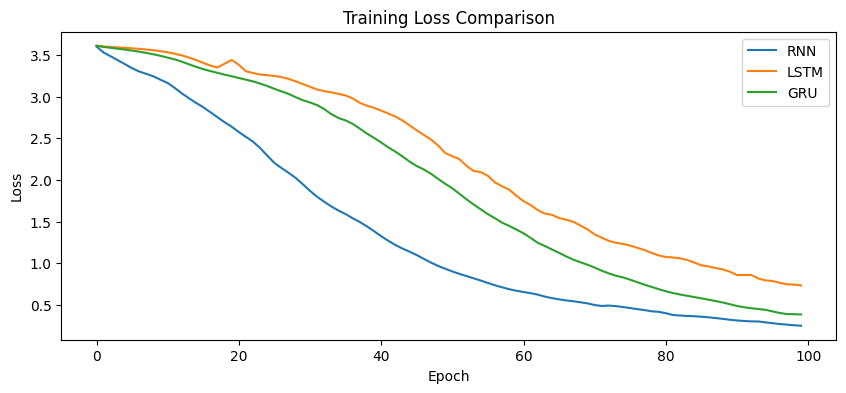

In [9]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [10]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [11]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence sentences
LSTM: deep learning models can generate meaningful sentences
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**